# 6) Compare Optimizers on Time-Lapse ERT (6x4)\n
\n
This notebook mirrors the temporal-regularization comparison layout:\n
- Rows 1-4: recovered snapshots with four optimizers\n
- Bottom row: yearly regolith representative-point resistivity trajectories (True + all optimizers)\n
- Uses coverage mask for map plotting\n

Regolith representative point: x=112.50 m, z=-7.37 m
Selected days: [1, 190, 294, 365]


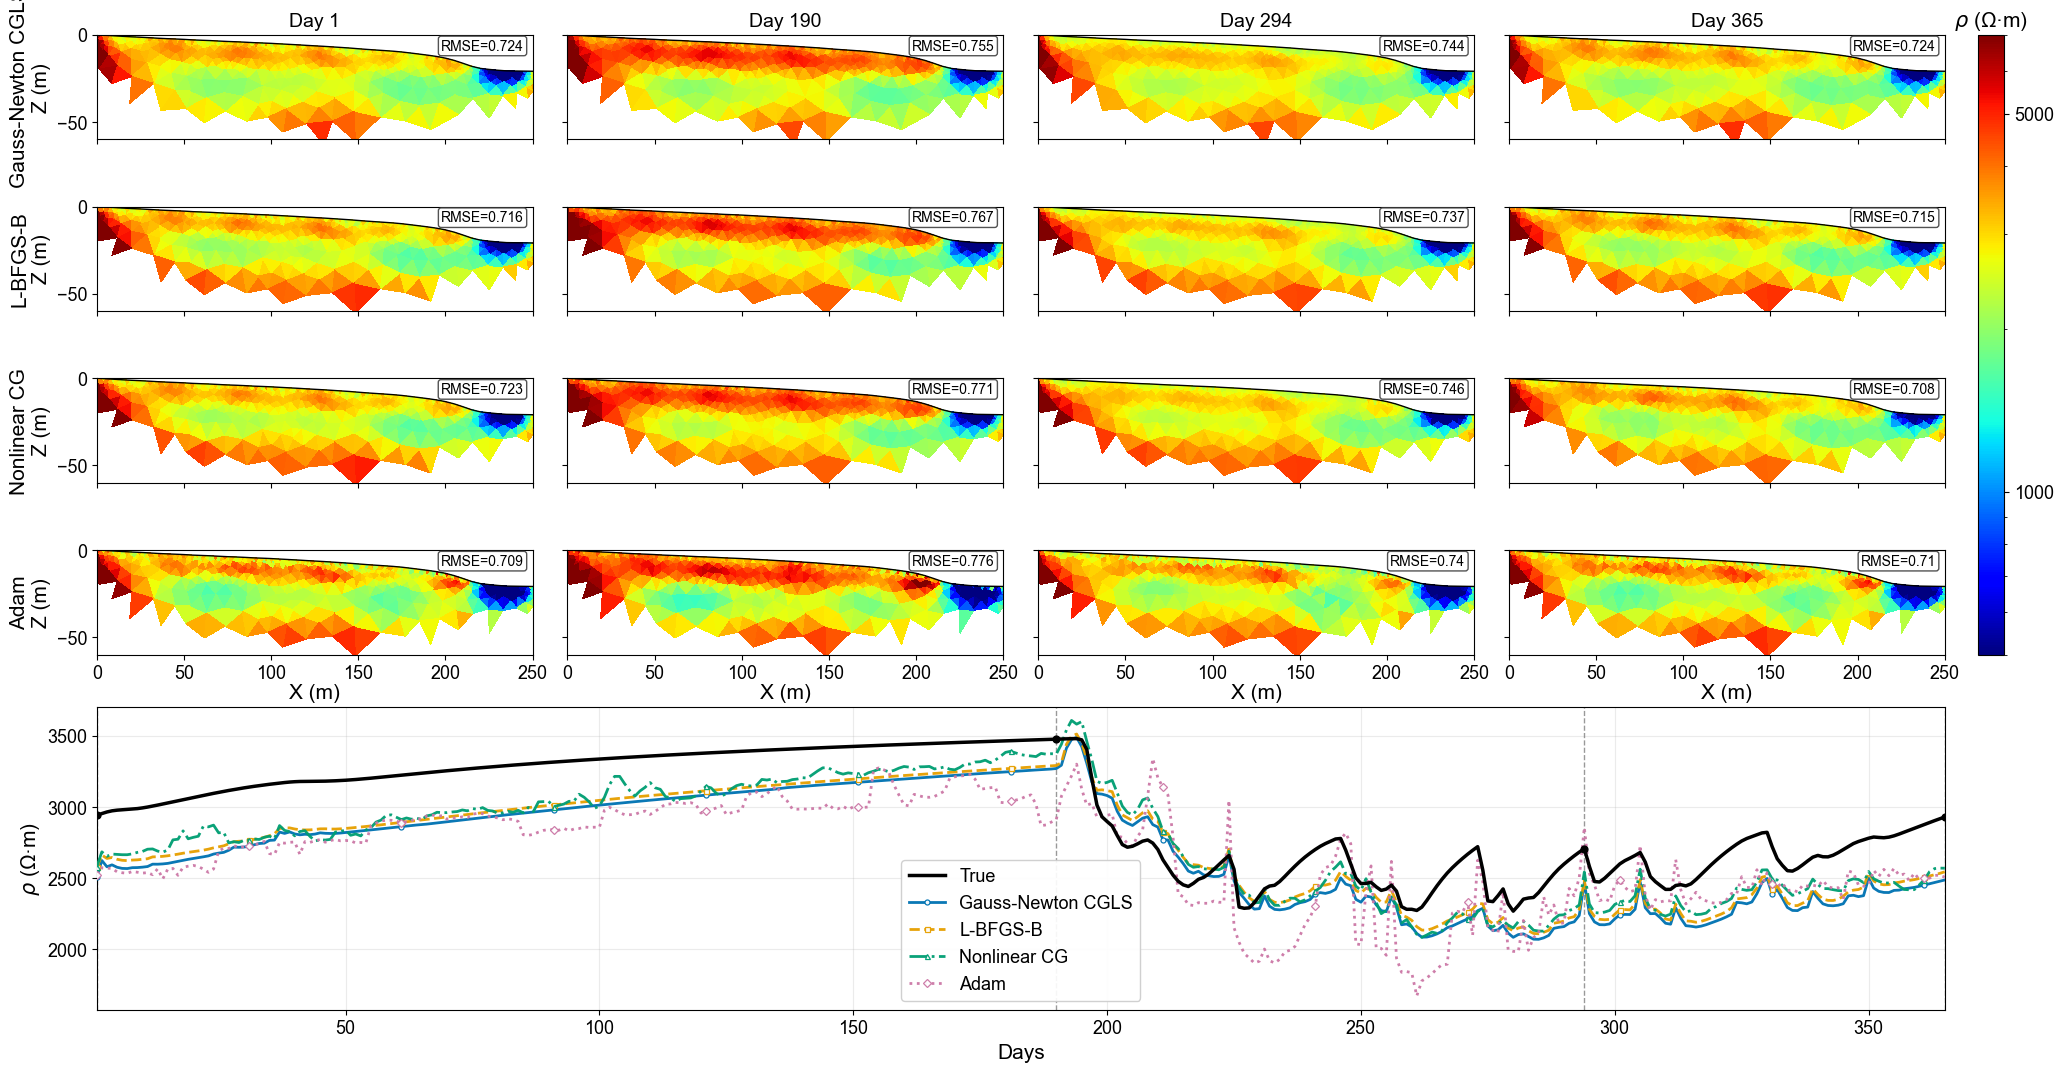

Saved: /home/luffy/deepertv1/result/6_optimization/6_compare_optimization.png

Optimization metrics summary (if available):
- Gauss-Newton CGLS  runtime[min]=10.981201108717748 max_rss[GB]=2.180511474609375 total_iters=    1904 final_obj=3.018695605408937
- L-BFGS-B           runtime[min]=23.604535446017206 max_rss[GB]=2.118255615234375 total_iters=    5445 final_obj=3.9134616392860226
- Nonlinear CG       runtime[min]=31.69030844451627 max_rss[GB]=2.116405487060547 total_iters=    5330 final_obj=4.288108675091867
- Adam               runtime[min]=44.35809063769993 max_rss[GB]=2.145183563232422 total_iters=    5445 final_obj=5.072074665296522


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from deepert.workflows.terrain import build_terrain_forward_case, parse_pftcl, read_slope_x

try:
    from parflow.tools.io import read_pfb
except Exception as exc:
    raise RuntimeError(
        "Failed to import parflow.tools.io.read_pfb. Run in project env: uv sync --extra examples"
    ) from exc

# ------------------------------------------------------------------
# A) Global setup (aligned with 0_rain_et_day_selection.ipynb)
# ------------------------------------------------------------------
# Font setup: prefer Arial when available; otherwise fall back cleanly.
import json
import logging
from matplotlib import font_manager

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

arial_candidates = [
    Path("/mnt/c/Windows/Fonts/arial.ttf"),
    Path("/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"),
    Path("/usr/share/fonts/truetype/msttcorefonts/arial.ttf"),
]
_use_arial = False
for _fp in arial_candidates:
    if _fp.exists():
        try:
            font_manager.fontManager.addfont(str(_fp))
            _use_arial = True
            break
        except Exception:
            pass

if _use_arial:
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
else:
    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

selected_days = [1, 190, 294, 365]
selected_steps = [(d - 1) * 24 for d in selected_days]
y_index = 2

axis_label_fs = 15
tick_label_fs = 13
title_fs = 14
legend_fs = 13
metric_fs = 10

optimizer_cases = [
    ("gauss_newton_cgls", "Gauss-Newton CGLS"),
    ("lbfgs_b", "L-BFGS-B"),
    ("nonlinear_cg", "Nonlinear CG"),
    ("adam", "Adam"),
]

# ------------------------------------------------------------------
# B) Resolve paths (robust: search upward from current working directory)
# ------------------------------------------------------------------
here = Path.cwd().resolve()
project_root = None
for candidate in [here, *here.parents]:
    if (candidate / "parflow_models").exists() and (candidate / "result").exists():
        project_root = candidate
        break

if project_root is None:
    raise FileNotFoundError(
        f"Cannot locate project root by walking upward from cwd={here}. "
        "Expected a directory containing both 'parflow_models' and 'result'."
    )

parflow_dir = project_root / "parflow_models"
resistivity_dir = project_root / "resistivity_models_2d"
optimizer_root = project_root / "result" / "6_optimization"

for key, _ in optimizer_cases:
    d = optimizer_root / key
    if not d.exists():
        raise FileNotFoundError(f"Missing optimizer result directory: {d}")

# ------------------------------------------------------------------
# C) Build physical terrain-following geometry (same style as day-selection notebook)
# ------------------------------------------------------------------
pftcl_path = parflow_dir / "sc2d_6.out.pftcl"
slope_x_path = parflow_dir / "sc2d_6.out.slope_x.pfb"
grid = parse_pftcl(pftcl_path)
slope_x = read_slope_x(slope_x_path, y_index=y_index)

rho_dummy = np.full((grid.nz, grid.nx), 100.0, dtype=float)
case_geom = build_terrain_forward_case(rho_dummy, grid, slope_x, y_index=y_index)

x_nodes = np.asarray(case_geom.x_nodes, dtype=float)
z_top = np.asarray(case_geom.z_top, dtype=float)
layer_thickness = np.asarray(case_geom.layer_thickness, dtype=float)

z_offsets = np.concatenate(([0.0], -np.cumsum(layer_thickness)))
Xn = np.tile(x_nodes[None, :], (grid.nz + 1, 1))
Zn = z_top[None, :] + z_offsets[:, None]

Xc = 0.25 * (Xn[:-1, :-1] + Xn[1:, :-1] + Xn[:-1, 1:] + Xn[1:, 1:])
Zc = 0.25 * (Zn[:-1, :-1] + Zn[1:, :-1] + Zn[:-1, 1:] + Zn[1:, 1:])

# class map for representative-point picking (top->bottom)
class_3d = np.asarray(read_pfb(str(parflow_dir / "class.pfb")), dtype=int)
class_td = class_3d[:, y_index, :][::-1, :]

# Flattened physical-grid cell centers for nearest-neighbor truth sampling to inversion meshes.
truth_xy = np.column_stack((Xc.ravel(), Zc.ravel()))


def _to_top_down(values_bottom_up: np.ndarray) -> np.ndarray:
    arr = np.asarray(values_bottom_up, dtype=float)
    if arr.shape != (grid.nz, grid.nx):
        raise ValueError(f"Expected {(grid.nz, grid.nx)}, got {arr.shape}")
    return arr[::-1, :]


def _pick_representative_cell(class_top_down: np.ndarray, cid: int, x_cell: np.ndarray, z_cell: np.ndarray):
    mask = class_top_down == int(cid)
    if not np.any(mask):
        raise ValueError(f"class {cid} not found")
    x_med = float(np.nanmedian(x_cell[mask]))
    z_med = float(np.nanmedian(z_cell[mask]))
    flat = np.flatnonzero(mask)
    x_vals = x_cell.ravel()[flat]
    z_vals = z_cell.ravel()[flat]
    dist2 = (x_vals - x_med) ** 2 + (z_vals - z_med) ** 2
    i_flat = int(flat[int(np.argmin(dist2))])
    iz, ix = np.unravel_index(i_flat, class_top_down.shape)
    return int(iz), int(ix), float(x_cell[iz, ix]), float(z_cell[iz, ix])


def _day_to_step(day: int) -> int:
    return (int(day) - 1) * 24


def _load_true_rho_td(step: int) -> np.ndarray:
    p = resistivity_dir / f"resistivity2d_y2_t{step:05d}.npy"
    if not p.exists():
        raise FileNotFoundError(f"Missing true model file: {p}")
    return _to_top_down(np.asarray(np.load(p), dtype=float))


# ------------------------------------------------------------------
# D) Representative point (Regolith, class 1) and true series
# ------------------------------------------------------------------
iz2, ix2, x_rep, z_rep = _pick_representative_cell(class_td, 1, Xc, Zc)

n_days = 365
true_series = np.full(n_days, np.nan, dtype=float)
true_snapshots: dict[int, np.ndarray] = {}
for day, step in zip(selected_days, selected_steps):
    true_snapshots[step] = _load_true_rho_td(step)
for d in range(1, n_days + 1):
    step = _day_to_step(d)
    true_series[d - 1] = float(_load_true_rho_td(step)[iz2, ix2])

print(f"Regolith representative point: x={x_rep:.2f} m, z={z_rep:.2f} m")
print("Selected days:", selected_days)

# ------------------------------------------------------------------
# E) Load inversion outputs for all optimizer cases
# ------------------------------------------------------------------
case_data = {}
for key, label in optimizer_cases:
    out_dir = optimizer_root / key
    steps = np.asarray(np.load(out_dir / "steps.npy"), dtype=int).ravel()
    models = np.asarray(np.load(out_dir / "final_models.npy"), dtype=float)
    mesh = np.load(out_dir / "timelapse_inversion_mesh.npz")
    nodes = np.asarray(mesh["nodes"], dtype=float)
    cells = np.asarray(mesh["cells"], dtype=np.int32)

    coverage_mask_path = out_dir / "coverage_mask.npy"
    coverage_mask = np.asarray(np.load(coverage_mask_path), dtype=bool).ravel()
    if coverage_mask.size != models.shape[0]:
        raise ValueError(
            f"{key}: coverage_mask size {coverage_mask.size} != n_cells {models.shape[0]}"
        )

    step_to_col = {int(s): i for i, s in enumerate(steps.tolist())}
    for step in selected_steps:
        if step not in step_to_col:
            raise KeyError(f"{key}: selected step t={step:05d} not in steps.npy")

    centers = nodes[cells].mean(axis=1)
    rep_idx = int(np.argmin((centers[:, 0] - x_rep) ** 2 + (centers[:, 1] - z_rep) ** 2))

    # Map inversion-cell centers to nearest physical-grid cell centers for RMSE_log.
    dist2 = (centers[:, [0]] - truth_xy[None, :, 0]) ** 2 + (centers[:, [1]] - truth_xy[None, :, 1]) ** 2
    truth_nn_idx = np.argmin(dist2, axis=1)

    snapshots = {step: models[:, step_to_col[step]] for step in selected_steps}
    day_axis = (steps // 24) + 1

    metrics = {}
    benchmark_path = out_dir / "optimization_benchmark.json"
    if benchmark_path.exists():
        try:
            metrics = json.loads(benchmark_path.read_text(encoding="utf-8"))
        except Exception:
            metrics = {}

    case_data[key] = {
        "label": label,
        "steps": steps,
        "models": models,
        "nodes": nodes,
        "cells": cells,
        "coverage_mask": coverage_mask,
        "rep_idx": rep_idx,
        "snapshots": snapshots,
        "series": models[rep_idx, :],
        "day_axis": day_axis,
        "truth_nn_idx": truth_nn_idx,
        "metrics": metrics,
    }

# ------------------------------------------------------------------
# F) Shared color scale for snapshot maps
# ------------------------------------------------------------------
positive_values = []
for step in selected_steps:
    arr = true_snapshots[step]
    positive_values.append(arr[np.isfinite(arr) & (arr > 0.0)])
for key, _ in optimizer_cases:
    for step in selected_steps:
        arr = np.asarray(case_data[key]["snapshots"][step], dtype=float)
        positive_values.append(arr[np.isfinite(arr) & (arr > 0.0)])

all_pos = np.concatenate([v for v in positive_values if v.size > 0])
rho_vmin = float(np.percentile(all_pos, 2.0))
rho_vmax = float(np.percentile(all_pos, 98.0))
if rho_vmax <= rho_vmin:
    rho_vmax = rho_vmin * 1.01
norm_rho = LogNorm(vmin=rho_vmin, vmax=rho_vmax)

# ------------------------------------------------------------------
# G) Plot controls (edit these for snapshot color ranges)
# ------------------------------------------------------------------
# Per-row color limits for the first 4 rows (Ω·m). Use None to keep shared auto range.
row_clim = [None, None, None, None]
apply_coverage_mask = True

# ------------------------------------------------------------------
# H) Plot: 4 map rows x 4 cols + bottom single time-series row
# ------------------------------------------------------------------
fig = plt.figure(figsize=(22, 11), constrained_layout=False)
gs = fig.add_gridspec(5, 4, height_ratios=[1.0, 1.0, 1.0, 1.0, 2.25], hspace=0.22, wspace=0.08)

axes_maps = np.empty((4, 4), dtype=object)
for r in range(4):
    for c in range(4):
        axes_maps[r, c] = fig.add_subplot(gs[r, c])
ax_series = fig.add_subplot(gs[4, :])

# Row labels (left side)
row_labels = [
    optimizer_cases[0][1],
    optimizer_cases[1][1],
    optimizer_cases[2][1],
    optimizer_cases[3][1],
]

# Keep references for one shared map colorbar
last_mappable = None

for col, (day, step) in enumerate(zip(selected_days, selected_steps)):
    # Column title
    axes_maps[0, col].set_title(f"Day {day}", fontsize=title_fs)

    # Rows 1-4: inversion snapshots (four optimizers)
    for r, (key, _) in enumerate(optimizer_cases):
        axr = axes_maps[r, col]
        nodes = case_data[key]["nodes"]
        cells = case_data[key]["cells"]
        vals = np.asarray(case_data[key]["snapshots"][step], dtype=float).copy()
        if apply_coverage_mask:
            # coverage_mask convention in inversion outputs: True => low coverage (masked-out)
            mask = np.asarray(case_data[key]["coverage_mask"], dtype=bool)
            vals[mask] = np.nan

        # RMSE in log-resistivity space, computed only in valid overlap.
        truth_idx = np.asarray(case_data[key]["truth_nn_idx"], dtype=int)
        true_vals_mesh = np.asarray(true_snapshots[step], dtype=float).ravel()[truth_idx]
        valid_rmse = np.isfinite(vals) & np.isfinite(true_vals_mesh) & (vals > 0.0) & (true_vals_mesh > 0.0)
        rmse_log = float(np.sqrt(np.mean((np.log(vals[valid_rmse]) - np.log(true_vals_mesh[valid_rmse])) ** 2))) if np.any(valid_rmse) else np.nan

        tm = axr.tripcolor(nodes[:, 0], nodes[:, 1], cells, vals, shading="flat", cmap="jet", norm=norm_rho)
        tm.set_clim(500, 7000)
        last_mappable = tm
        axr.plot(x_nodes, z_top, "k-", lw=1.0)
        axr.text(
            0.98,
            0.96,
            f"RMSE={rmse_log:.3g}",
            transform=axr.transAxes,
            ha="right",
            va="top",
            fontsize=metric_fs,
            bbox=dict(facecolor="white", edgecolor="0.25", alpha=0.90, boxstyle="round,pad=0.20"),
            zorder=7,
        )

# Shared formatting for map rows (4x4)
for r in range(4):
    for c in range(4):
        ax = axes_maps[r, c]
        ax.set_xlim(float(x_nodes.min()), float(x_nodes.max()))
        ax.set_ylim(-60.0, 0.0)
        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(axis="both", labelsize=tick_label_fs)
        if r < 3:
            ax.tick_params(axis="x", labelbottom=False)
        else:
            ax.set_xlabel("X (m)", fontsize=axis_label_fs, labelpad=1)
        if c > 0:
            ax.tick_params(axis="y", labelleft=False)

for r in range(4):
    axes_maps[r, 0].set_ylabel(f"{row_labels[r]}\nZ (m)", fontsize=axis_label_fs)

# Bottom row: single yearly trajectory axis (true + 4 optimizers)
days = np.arange(1, n_days + 1, dtype=int)
ax_series.plot(days, true_series, color="black", lw=2.5, ls="-", label="True", zorder=5)

# Colorblind-friendly styles for optimizer comparison curves.
series_styles = {
    "gauss_newton_cgls": {"color": "#0072B2", "ls": "-", "marker": "o"},
    "lbfgs_b": {"color": "#E69F00", "ls": "--", "marker": "s"},
    "nonlinear_cg": {"color": "#009E73", "ls": "-.", "marker": "^"},
    "adam": {"color": "#CC79A7", "ls": ":", "marker": "D"},
}
for key, label in optimizer_cases:
    st = series_styles.get(key, {"color": "0.35", "ls": "-", "marker": None})
    ax_series.plot(
        case_data[key]["day_axis"],
        case_data[key]["series"],
        lw=2.0,
        color=st["color"],
        ls=st["ls"],
        marker=st["marker"],
        ms=3.6,
        markevery=30,
        mfc="white",
        mew=0.9,
        alpha=0.96,
        label=label,
        zorder=4,
    )
for d in selected_days:
    ax_series.axvline(d, color="gray", ls="--", lw=1.0, alpha=0.8)
    ax_series.scatter([d], [true_series[d - 1]], color="black", s=24, zorder=6)

ax_series.set_xlim(1, n_days)
ax_series.grid(alpha=0.25)
ax_series.tick_params(axis="both", labelsize=tick_label_fs)
ax_series.set_xlabel("Days", fontsize=axis_label_fs)
ax_series.set_ylabel(r"$\rho$ (Ω·m)", fontsize=axis_label_fs)
ax_series.legend(loc="best", fontsize=legend_fs, frameon=True, framealpha=0.92, fancybox=True)

# Shared colorbar for the 4x4 map block, placed outside to avoid overlap
fig.subplots_adjust(left=0.06, right=0.90, top=0.96, bottom=0.06)
if last_mappable is not None:
    # Colorbar spans only the first 4 map rows.
    top_maps = axes_maps[0, 0].get_position().y1
    bottom_maps = axes_maps[3, 0].get_position().y0
    right_maps = axes_maps[0, 3].get_position().x1
    cax = fig.add_axes([right_maps + 0.015, bottom_maps, 0.012, top_maps - bottom_maps])
    cbar = fig.colorbar(last_mappable, cax=cax)
    cbar.set_ticks([1000, 5000])
    cbar.set_ticklabels(["1000", "5000"])
    cbar.ax.set_title(r"$\rho$ (Ω·m)", fontsize=axis_label_fs)
    cbar.ax.tick_params(labelsize=tick_label_fs)

out_png = optimizer_root / "6_compare_optimization.png"
fig.savefig(out_png, dpi=600)
plt.show()

print("Saved:", out_png)

print("\nOptimization metrics summary (if available):")
for key, label in optimizer_cases:
    m = case_data[key].get("metrics", {})
    runtime_min = m.get("runtime_wall_min")
    mem_gb = m.get("max_rss_gb")
    total_iter = m.get("total_iterations")
    final_obj = m.get("final_objective_value")
    print(
        f"- {label:18s} "
        f"runtime[min]={runtime_min!s:>8} "
        f"max_rss[GB]={mem_gb!s:>8} "
        f"total_iters={total_iter!s:>8} "
        f"final_obj={final_obj!s}"
    )
